In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("../bench_results_cache/5-nbeap.csv")
df.head()

,op,size,cpu_time,cpu_time_2removedInsertRecursion,cpu_time_3ss,cpu_time_4withBubbleUp,cpu_time_5withoutBubbleUp
0,Construct,256.0,8.71207,8.50186,32.7892,7.89595,7.37875
1,Construct,1024.0,27.77010,25.98520,96.4296,25.57000,26.12680
2,Construct,4096.0,27.55920,25.43480,83.3352,25.11750,25.36440
3,Construct,16384.0,17.80890,16.61610,61.2765,16.94860,17.13140
4,Construct,65536.0,16.66650,15.74160,59.4417,16.01000,16.13660


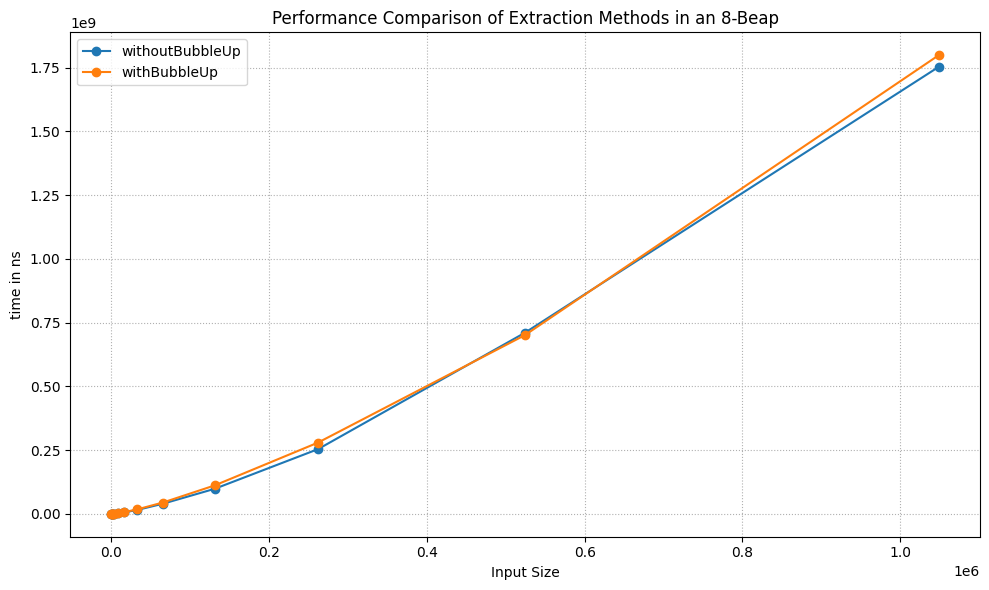

In [3]:
otherCols = ["op", "size"]
labelMap = {
    "cpu_time_5withoutBubbleUp" : "withoutBubbleUp", 
    "cpu_time_4withBubbleUp" : "withBubbleUp"
            }
colsToPlot = ["cpu_time_5withoutBubbleUp", "cpu_time_4withBubbleUp"]
df_extract = df[df["op"] == "Extract"] 
df_extract = df_extract.sort_values("size")

plt.figure(figsize=(10,6))
plt.title(f"Performance Comparison of Extraction Methods in an 8-Beap")
plt.xlabel("Input Size")
plt.ylabel("time in ns")
# plt.xscale("log", base=2)
# plt.yscale("log", base=2)
# plt.ylim(bottom=0)

x = df_extract["size"].to_numpy()

for col in colsToPlot:
    y = df_extract[col].to_numpy()
    plt.plot(x, y, marker="o", label=labelMap[col])
    #print(y)

plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv("../bench_results_cache/5-nbeap.csv")
df.head()

,op,size,cpu_time2withoutBubbleUp,stat,cpu_time_3withBubbleUp
0,Construct,256.0,7.346900,mean,7.523510
1,Construct,256.0,7.325790,median,7.433640
2,Construct,256.0,0.096934,stddev,0.243152
3,Construct,256.0,0.013194,cv,0.032319
4,Construct,256.0,7.449990,p90,7.609640


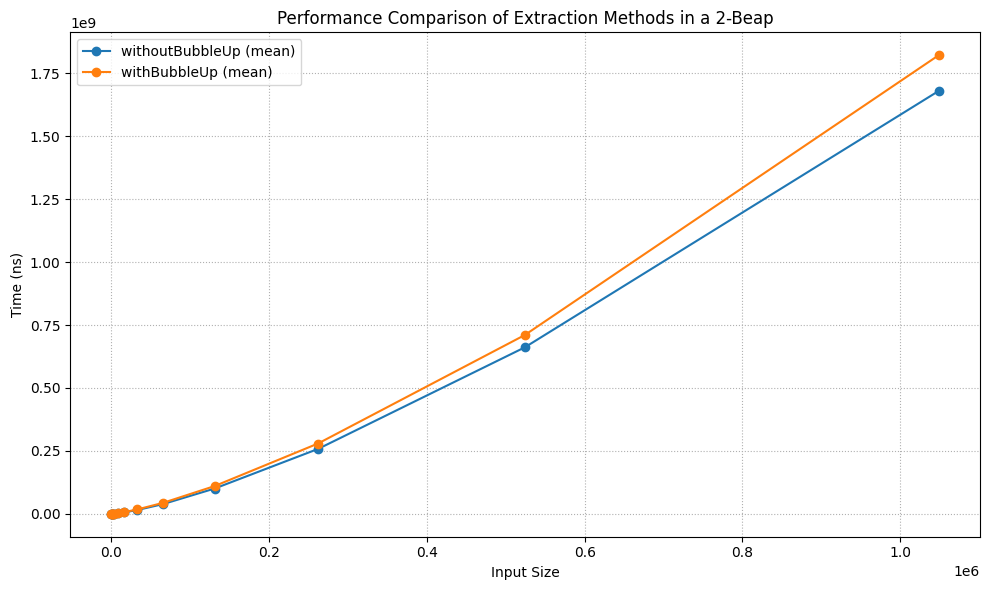

In [ ]:

labelMap = {
    "cpu_time2withoutBubbleUp": "withoutBubbleUp",
    "cpu_time_3withBubbleUp": "withBubbleUp"
}

baseCols = ["cpu_time2withoutBubbleUp", "cpu_time_3withBubbleUp"]

df_extract = df[df["op"] == "Extract"].copy()
df_extract["size"] = pd.to_numeric(df_extract["size"])

df_plot = df_extract.pivot(index="size", columns="stat", values=baseCols)
df_plot = df_plot.sort_index()

plt.figure(figsize=(10, 6))
plt.title("Performance Comparison of Extraction Methods in a 2-Beap")
plt.xlabel("Input Size")
plt.ylabel("Time (ns)")
# plt.xscale("log", base=2)
# plt.yscale("log", base=10)

x = df_plot.index.to_numpy()

for base in baseCols:
    y_mean = df_plot[(base, "median")].to_numpy()
    plt.plot(x, y_mean, marker="o", label=f"{labelMap[base]} (mean)")

plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()